In [24]:
import shlex
import subprocess
from pathlib import Path
from typing import Callable
from dotenv import load_dotenv
from skills_ref import to_prompt
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.messages import SystemMessage
from langchain_core.messages import HumanMessage
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

load_dotenv()

True

In [25]:
@tool
def get_skill_instruction(skill_name: str) -> str:
    """获取指定技能的详细指令及脚本清单。"""
    base = Path("./skills") / skill_name
    file = base / "SKILL.md"

    if not file.exists():
        return f"错误：找不到技能 {skill_name}"

    content = file.read_text(encoding="utf-8")
    body = content.split("---")[-1].strip()

    scripts = [f.name for f in (base / "scripts").glob("*") if f.is_file()]
    script_info = f"\n\n📂 **可用脚本**: {', '.join(scripts)}" if scripts else "\n\n📂 **可用脚本**: 无"

    return (
        f"# {skill_name} 详情\n"
        f"📍 **技能路径**: `{base}`\n\n"
        f"{body}"
        f"{script_info}"
    )


@tool
def run_shell_command(command: str) -> str:
    """
    执行系统命令行指令。
    注意：如果参数里有 JSON，请用单引号包裹整个 JSON，JSON 内部的代码请只用双引号。
    """
    try:
        args = shlex.split(command)

        result = subprocess.run(
            args,
            shell=False,
            capture_output=True,
            text=True,
            timeout=300
        )

        output = result.stdout + result.stderr
        return f"状态码: {result.returncode}\n输出内容: {output if output else '执行成功，无输出'}"

    except Exception as e:
        return f"执行出错: {str(e)}"


@wrap_model_call
def add_context(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    skills_root = Path("./skills")
    skill_paths = [p for p in skills_root.iterdir() if p.is_dir() and (p / "SKILL.md").exists()]
    skills_catalog = to_prompt(skill_paths)
    system_prompt = f"""
# Role
你是一个功能强大的通用人工智能助手。为了更高效、精准地完成复杂任务，你拥有访问“专用技能库”的权限。

# 技能目录 (Skill Catalog)
以下是你当前可以调用的扩展技能列表。每个技能包含名称和核心功能简述：

{skills_catalog}

# 核心操作逻辑 (Operating Logic)
当你处理用户请求时，请遵循以下决策流程：

1. **意图匹配**：判断用户需求是否落在上述 [技能目录] 的覆盖范围内。
2. **按需检索**：如果你决定使用某个技能，**严禁凭经验盲目猜测其操作细节**。你必须立即调用工具 `get_skill_instruction(skill_name)` 来获取该技能的“详细操作手册”。
3. **知识利用**：
    - 阅读手册中提供的执行步骤、参数规范及约束条件。
    - 如果手册中提到需要运行特定的脚本（通常位于 `skills/技能名/scripts/`），请严格按照说明执行对应的命令行操作。
4. **组合执行**：你可以根据任务复杂度，依次检索并利用多个技能来构建完整的解决方案。

# 行为约束
- **先读后做**：在未获取详细指令前，不得尝试调用该技能目录下的任何脚本或文件。
- **路径感知**：使用相对于当前工作目录的完整路径。
- **Shell 转义安全 (重要)**：
    - 当使用 `run_shell_command` 执行包含复杂参数（如 JSON）的命令时，**必须**使用单引号 `'` 包裹整个 JSON 字符串。
    - 在单引号包裹的 JSON 内部，**必须**使用双引号 `"` 来界定键和值。
    - 示例正确格式：`--scripts '{{"main.py": "print(1)"}}'`
- **结果导向**：利用技能解决问题后，简洁反馈结果。
"""
    system_message = SystemMessage(content=system_prompt)
    return handler(request.override(system_message=system_message))

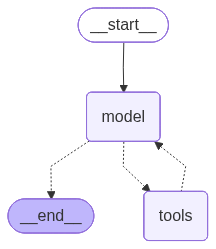

In [26]:
agent = create_agent(ChatOpenAI(model="qwen-plus"), tools=[get_skill_instruction, run_shell_command],
                     middleware=[add_context])
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [19]:
user_query = "现在几点了"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 10}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

现在几点了
================================== Ai Message ==================================

我无法获取当前的实时时间。建议您查看设备系统时间，或使用手机、电脑等终端的时钟功能确认当前时间。


In [22]:
user_query = "帮我创建一个可以获取时间的技能。"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 10}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

帮我创建一个可以获取时间的技能。
================================== Ai Message ==================================

我需要为您创建一个获取时间的技能。首先，让我获取skill-factory技能的详细指令，以便了解如何正确构建这个新技能。
Tool Calls:
  get_skill_instruction (call_1db9d41892074be7849dad)
 Call ID: call_1db9d41892074be7849dad
  Args:
    skill_name: skill-factory
================================= Tool Message =================================
Name: get_skill_instruction

# skill-factory 详情
📍 **技能路径**: `skills/skill-factory`

# Skill Factory (技能工厂)

你是技能架构师。你的目标不只是生成代码，而是创造能精准解决问题、易于触发且鲁棒性强的 Agent 能力模块。

## 🛠 核心工作流

### 1. 意图捕获与深度调研 (Capture & Research)

在调用构建脚本前，必须先理清以下问题：

- **核心目标**：这个技能到底要帮用户完成什么任务？
- **触发场景**：用户在什么语境下会用到它？（描述需要略微“强势”，涵盖潜在的模糊需求）。
- **预期产出**：输出是什么格式？（Markdown 报告、JSON 数据、还是特定的文件修改？）。
- **依赖识别**：是否需要编写 Python 脚本处理逻辑？是否需要参考特定的文档（References）？

### 2. 内容构思与设计 (Content Design)

基于调研，构思技能的四个组成部分：

- **Instructions (核心)**：编写逻辑清晰、基于原则（而非死板命令）的 Markdown 指令。


In [23]:
user_query = "现在几点了"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 10}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

现在几点了
================================== Ai Message ==================================
Tool Calls:
  get_skill_instruction (call_2f76c49c976d41dd9224f2)
 Call ID: call_2f76c49c976d41dd9224f2
  Args:
    skill_name: get-time
================================= Tool Message =================================
Name: get_skill_instruction

# get-time 详情
📍 **技能路径**: `skills/get-time`

# get-time

# 获取当前时间\n\n## 功能说明\n本技能用于获取并返回当前系统时间。\n\n## 使用方法\n直接调用本技能即可获得当前时间信息。\n\n## 输出格式\n返回格式为：YYYY-MM-DD HH:MM:SS

📂 **可用脚本**: main.py
================================== Ai Message ==================================
Tool Calls:
  run_shell_command (call_7e9a73f333674f2fa13980)
 Call ID: call_7e9a73f333674f2fa13980
  Args:
    command: python skills/get-time/scripts/main.py
================================= Tool Message =================================
Name: run_shell_command

状态码: 0
输出内容: 2026-03-10 21:54:18

=================